In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

majors = pd.read_csv("degrees-that-pay-back.csv")
college_type = pd.read_csv("salaries-by-college-type.csv")
region = pd.read_csv("salaries-by-region.csv")

In [3]:
def clean_money(series):
    return (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace(".00", "", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

In [4]:
major_money_cols = [
    "Starting Median Salary",
    "Mid-Career Median Salary",
    "Percent change from Starting to Mid-Career Salary",
    "Mid-Career 10th Percentile Salary",
    "Mid-Career 25th Percentile Salary",
    "Mid-Career 75th Percentile Salary",
    "Mid-Career 90th Percentile Salary"
]

for col in major_money_cols:
    if col == "Percent change from Starting to Mid-Career Salary":
        majors[col] = (
            majors[col].astype(str)
            .str.replace("%", "", regex=False)
            .replace("nan", np.nan)
            .astype(float)
        )
    else:
        majors[col] = clean_money(majors[col])

In [5]:
type_money_cols = [
    "Starting Median Salary",
    "Mid-Career Median Salary",
    "Mid-Career 10th Percentile Salary",
    "Mid-Career 25th Percentile Salary",
    "Mid-Career 75th Percentile Salary",
    "Mid-Career 90th Percentile Salary"
]

for col in type_money_cols:
    college_type[col] = clean_money(college_type[col])

In [6]:
region_money_cols = [
    "Starting Median Salary",
    "Mid-Career Median Salary",
    "Mid-Career 10th Percentile Salary",
    "Mid-Career 25th Percentile Salary",
    "Mid-Career 75th Percentile Salary",
    "Mid-Career 90th Percentile Salary"
]

for col in region_money_cols:
    region[col] = clean_money(region[col])

In [7]:
majors["Salary Growth ($)"] = (
    majors["Mid-Career Median Salary"] - majors["Starting Median Salary"]
)

majors["Salary Growth (%)"] = (
    (majors["Mid-Career Median Salary"] - majors["Starting Median Salary"])
    / majors["Starting Median Salary"]
) * 100

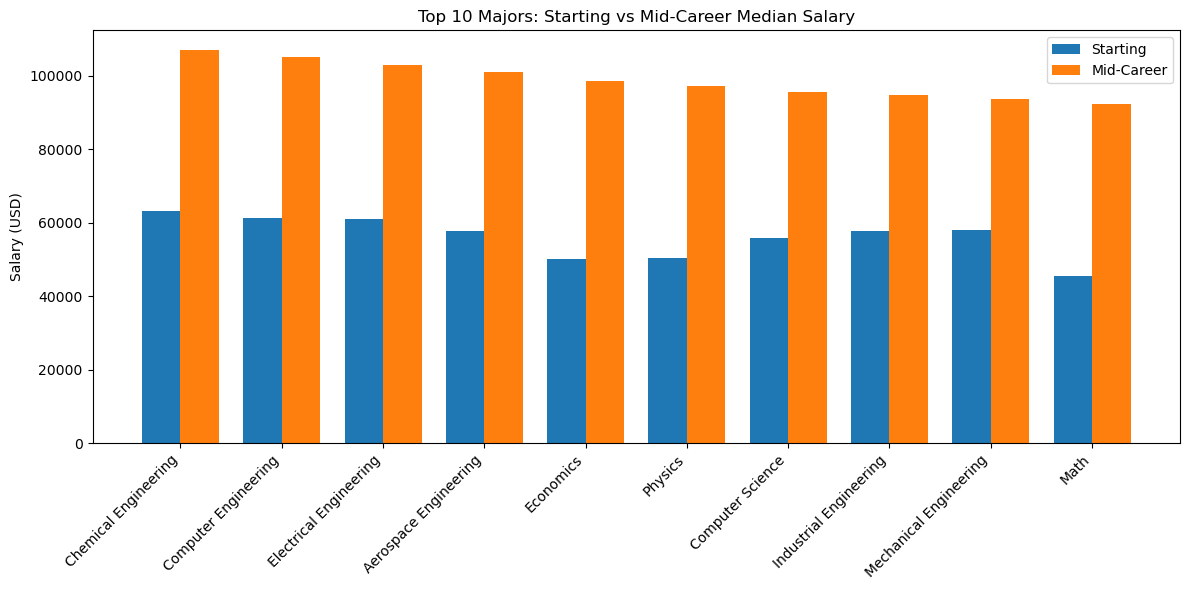

In [26]:
top_majors = majors.sort_values("Mid-Career Median Salary", ascending=False).head(10)

x = np.arange(len(top_majors))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, top_majors["Starting Median Salary"], width=width, label="Starting")
plt.bar(x + width/2, top_majors["Mid-Career Median Salary"], width=width, label="Mid-Career")

plt.xticks(x, top_majors["Undergraduate Major"], rotation=45, ha="right")
plt.ylabel("Salary (USD)")
plt.title("Top 10 Majors: Starting vs Mid-Career Median Salary")
plt.legend()
plt.tight_layout()
plt.savefig("draft_visualizations/start_vs_mid.png", dpi=400, bbox_inches="tight")
plt.show()

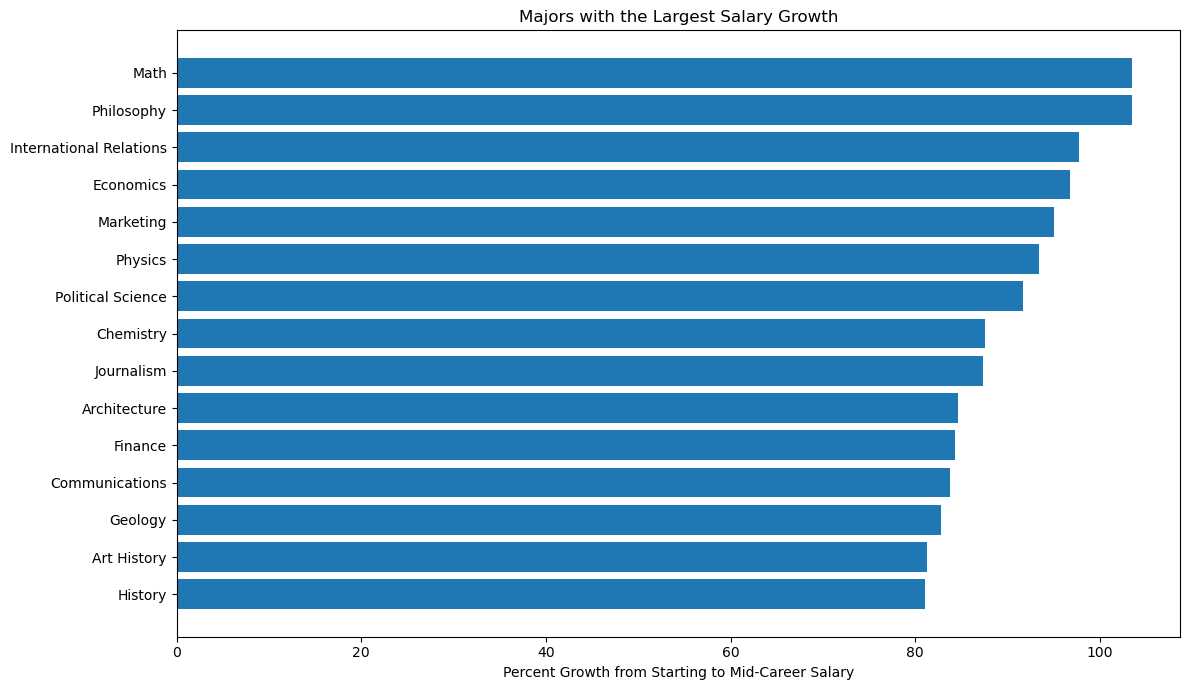

In [27]:
top_growth = majors.sort_values("Salary Growth (%)", ascending=False).head(15)

plt.figure(figsize=(12, 7))
plt.barh(top_growth["Undergraduate Major"], top_growth["Salary Growth (%)"])

plt.xlabel("Percent Growth from Starting to Mid-Career Salary")
plt.title("Majors with the Largest Salary Growth")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("draft_visualizations/growth", dpi=400, bbox_inches="tight")
plt.show()

In [10]:
combined_schools = pd.merge(
    region[["School Name", "Region", "Starting Median Salary", "Mid-Career Median Salary"]],
    college_type[["School Name", "School Type"]],
    on="School Name",
    how="inner"
)

combined_schools.head()

,School Name,Region,Starting Median Salary,Mid-Career Median Salary,School Type
0,California Institute of Technology (CIT),California,75500.0,123000.0,Engineering
1,Harvey Mudd College,California,71800.0,122000.0,Engineering
2,"University of California, Berkeley",California,59900.0,112000.0,State
3,Occidental College,California,51900.0,105000.0,Liberal Arts
4,Cal Poly San Luis Obispo,California,57200.0,101000.0,State


In [15]:
import plotly.graph_objects as go

In [16]:
plot_df = combined_schools.dropna(subset=[
    "School Name",
    "Region",
    "School Type",
    "Starting Median Salary",
    "Mid-Career Median Salary"
]).copy()

plot_df.head()

,School Name,Region,Starting Median Salary,Mid-Career Median Salary,School Type
0,California Institute of Technology (CIT),California,75500.0,123000.0,Engineering
1,Harvey Mudd College,California,71800.0,122000.0,Engineering
2,"University of California, Berkeley",California,59900.0,112000.0,State
3,Occidental College,California,51900.0,105000.0,Liberal Arts
4,Cal Poly San Luis Obispo,California,57200.0,101000.0,State


In [17]:
regions = sorted(plot_df["Region"].unique())
school_types = sorted(plot_df["School Type"].unique())

fig = go.Figure()

trace_info = []

# Trace 0: all schools
fig.add_trace(
    go.Scatter(
        x=plot_df["Starting Median Salary"],
        y=plot_df["Mid-Career Median Salary"],
        mode="markers",
        text=plot_df["School Name"],
        customdata=np.stack([plot_df["Region"], plot_df["School Type"]], axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Region: %{customdata[0]}<br>"
            "School Type: %{customdata[1]}<br>"
            "Starting Salary: $%{x:,.0f}<br>"
            "Mid-Career Salary: $%{y:,.0f}<extra></extra>"
        ),
        name="All Schools",
        visible=True
    )
)
trace_info.append("All Schools")

# Region-only traces
for region_name in regions:
    df_sub = plot_df[plot_df["Region"] == region_name]
    fig.add_trace(
        go.Scatter(
            x=df_sub["Starting Median Salary"],
            y=df_sub["Mid-Career Median Salary"],
            mode="markers",
            text=df_sub["School Name"],
            customdata=np.stack([df_sub["Region"], df_sub["School Type"]], axis=-1),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Region: %{customdata[0]}<br>"
                "School Type: %{customdata[1]}<br>"
                "Starting Salary: $%{x:,.0f}<br>"
                "Mid-Career Salary: $%{y:,.0f}<extra></extra>"
            ),
            name=f"Region: {region_name}",
            visible=False
        )
    )
    trace_info.append(f"Region: {region_name}")

# Type-only traces
for type_name in school_types:
    df_sub = plot_df[plot_df["School Type"] == type_name]
    fig.add_trace(
        go.Scatter(
            x=df_sub["Starting Median Salary"],
            y=df_sub["Mid-Career Median Salary"],
            mode="markers",
            text=df_sub["School Name"],
            customdata=np.stack([df_sub["Region"], df_sub["School Type"]], axis=-1),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Region: %{customdata[0]}<br>"
                "School Type: %{customdata[1]}<br>"
                "Starting Salary: $%{x:,.0f}<br>"
                "Mid-Career Salary: $%{y:,.0f}<extra></extra>"
            ),
            name=f"Type: {type_name}",
            visible=False
        )
    )
    trace_info.append(f"Type: {type_name}")

# Region + type traces
for region_name in regions:
    for type_name in school_types:
        df_sub = plot_df[
            (plot_df["Region"] == region_name) &
            (plot_df["School Type"] == type_name)
        ]

        fig.add_trace(
            go.Scatter(
                x=df_sub["Starting Median Salary"],
                y=df_sub["Mid-Career Median Salary"],
                mode="markers",
                text=df_sub["School Name"],
                customdata=np.stack([df_sub["Region"], df_sub["School Type"]], axis=-1) if len(df_sub) > 0 else None,
                hovertemplate=(
                    "<b>%{text}</b><br>"
                    "Region: %{customdata[0]}<br>"
                    "School Type: %{customdata[1]}<br>"
                    "Starting Salary: $%{x:,.0f}<br>"
                    "Mid-Career Salary: $%{y:,.0f}<extra></extra>"
                ),
                name=f"{region_name} + {type_name}",
                visible=False
            )
        )
        trace_info.append(f"{region_name} + {type_name}")

In [18]:
buttons = []

for i, label in enumerate(trace_info):
    visible = [False] * len(trace_info)
    visible[i] = True

    buttons.append(
        dict(
            label=label,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Starting vs Mid-Career Salary by School<br><sup>{label}</sup>"}
            ]
        )
    )

fig.update_layout(
    title="Starting vs Mid-Career Salary by School<br><sup>All Schools</sup>",
    xaxis_title="Starting Median Salary ($)",
    yaxis_title="Mid-Career Median Salary ($)",
    width=950,
    height=650,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1,
            yanchor="top"
        )
    ]
)

fig.show()

In [29]:
regions = ["All"] + sorted(plot_df["Region"].unique().tolist())
school_types = sorted(plot_df["School Type"].unique().tolist())

fig = go.Figure()

trace_labels = []

for region_name in regions:
    if region_name == "All":
        region_df = plot_df.copy()
    else:
        region_df = plot_df[plot_df["Region"] == region_name]

    for school_type in school_types:
        df_sub = region_df[region_df["School Type"] == school_type]

        fig.add_trace(
            go.Scatter(
                x=df_sub["Starting Median Salary"],
                y=df_sub["Mid-Career Median Salary"],
                mode="markers",
                name=school_type,
                text=df_sub["School Name"],
                customdata=np.stack(
                    [df_sub["Region"], df_sub["School Type"]],
                    axis=-1
                ) if len(df_sub) > 0 else None,
                hovertemplate=(
                    "<b>%{text}</b><br>"
                    "Region: %{customdata[0]}<br>"
                    "School Type: %{customdata[1]}<br>"
                    "Starting Salary: $%{x:,.0f}<br>"
                    "Mid-Career Salary: $%{y:,.0f}<extra></extra>"
                ),
                visible=(region_name == "All")
            )
        )

    trace_labels.append(region_name)

In [31]:
buttons = []
num_types = len(school_types)

for i, region_name in enumerate(trace_labels):
    visible = [False] * len(fig.data)
    start = i * num_types
    end = start + num_types

    for j in range(start, end):
        visible[j] = True

    buttons.append(
        dict(
            label=region_name,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Starting vs Mid-Career Salary by School<br><sup>Region: {region_name}</sup>"}
            ]
        )
    )

fig.update_layout(
    title="Starting vs Mid-Career Salary by School<br><sup>Region: All</sup>",
    xaxis_title="Starting Median Salary ($)",
    yaxis_title="Mid-Career Median Salary ($)",
    width=950,
    height=650,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1,
            yanchor="top"
        )
    ],
    legend_title="School Type"
)
fig.write_html("draft_visualizations/interactive_plot.html", full_html=True)
fig.show()

In [22]:
type_summary = college_type.groupby("School Type", as_index=False).mean(numeric_only=True)
type_summary

,School Type,Starting Median Salary,Mid-Career Median Salary,Mid-Career 10th Percentile Salary,Mid-Career 25th Percentile Salary,Mid-Career 75th Percentile Salary,Mid-Career 90th Percentile Salary
0,Engineering,59057.894737,103842.105263,61793.333333,81384.210526,134868.421053,173333.333333
1,Ivy League,60475.000000,120125.000000,57900.000000,82787.500000,184125.000000,269625.000000
2,Liberal Arts,45746.808511,89378.723404,47478.571429,61936.170213,131076.595745,191142.857143
3,Party,45715.000000,84685.000000,44052.631579,60005.000000,118100.000000,166947.368421
4,State,44126.285714,78567.428571,41886.285714,56689.714286,106970.857143,147571.428571


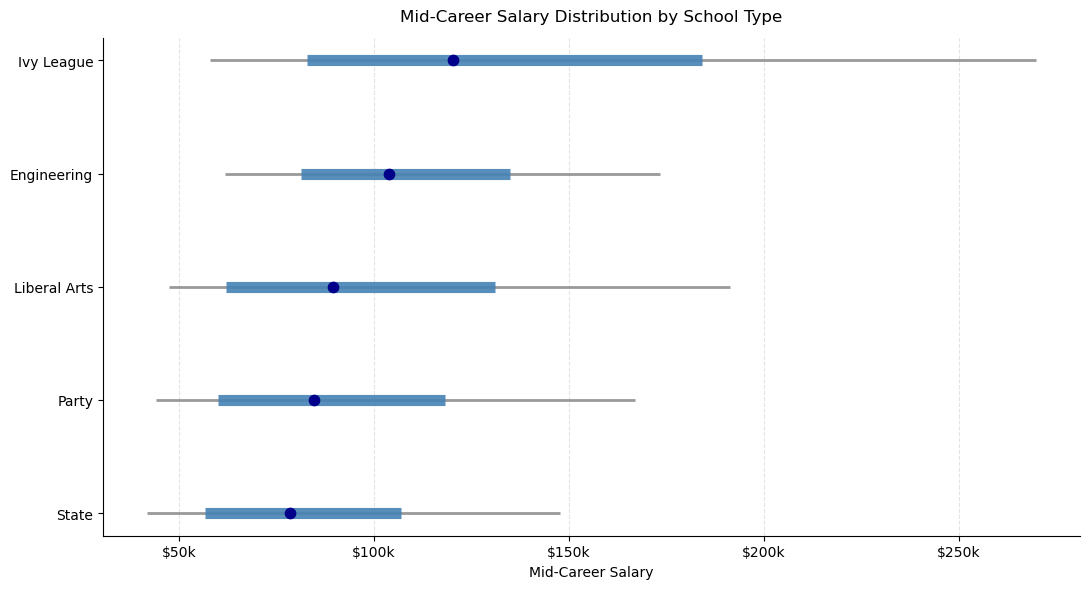

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

type_summary = college_type.groupby("School Type", as_index=False).mean(numeric_only=True)
type_summary = type_summary.sort_values("Mid-Career Median Salary", ascending=True)

y = np.arange(len(type_summary))

fig, ax = plt.subplots(figsize=(11, 6))

# 10th to 90th percentile range
ax.hlines(
    y,
    type_summary["Mid-Career 10th Percentile Salary"],
    type_summary["Mid-Career 90th Percentile Salary"],
    color="gray",
    linewidth=2,
    alpha=0.8,
    zorder=1
)

# 25th to 75th percentile range
ax.hlines(
    y,
    type_summary["Mid-Career 25th Percentile Salary"],
    type_summary["Mid-Career 75th Percentile Salary"],
    color="steelblue",
    linewidth=8,
    alpha=0.9,
    zorder=2
)

# median points
ax.scatter(
    type_summary["Mid-Career Median Salary"],
    y,
    color="darkblue",
    s=55,
    zorder=3,
    label="Median"
)

# labels
ax.set_yticks(y)
ax.set_yticklabels(type_summary["School Type"])
ax.set_xlabel("Mid-Career Salary")
ax.set_title("Mid-Career Salary Distribution by School Type", pad=12)

# format x-axis as dollars in thousands
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# grid and cleanup
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("draft_visualizations/school_type_dist", dpi=400, bbox_inches="tight")
plt.show()